# Temperature & Autoregressive Decoding: How Language Models Generate Text

In the previous notebook, we built a small autoregressive language model that learned to predict the next token.

This notebook focuses on what happens after training. A trained language model gives us a probability distribution over possible next tokens. Decoding decides how those probabilities are used to generate text.

## Introduction

Training teaches the model probabilities. Inference decides how those probabilities are used.

Different decoding strategies can produce very different outputs from the same probability distribution. Greedy decoding may be stable but repetitive. Sampling can be more creative but less predictable. Temperature, top-k, and top-p sampling give us practical controls over that trade-off.

In [1]:
import random
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

## From Training to Inference

A language model learns to output probabilities during training. During inference, generation repeats a simple loop:

Training → Probability Distribution → Sampling → Generated Token → Repeat

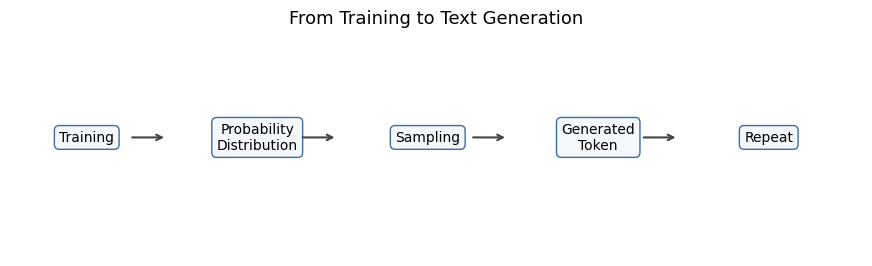

In [2]:
pipeline_steps = [
    "Training",
    "Probability\nDistribution",
    "Sampling",
    "Generated\nToken",
    "Repeat",
]

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")
ax.set_xlim(0, len(pipeline_steps))
ax.set_ylim(0, 1)

for idx, step in enumerate(pipeline_steps):
    ax.text(
        idx + 0.45,
        0.55,
        step,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#f5f8fb", edgecolor="#3b6ea8"),
        fontsize=10,
    )
    if idx < len(pipeline_steps) - 1:
        ax.annotate(
            "",
            xy=(idx + 0.92, 0.55),
            xytext=(idx + 0.70, 0.55),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#444444"),
        )

ax.set_title("From Training to Text Generation", fontsize=13, pad=12)
plt.show()

## Probability Distribution

At each generation step, the model predicts a probability for every possible next token.

The highest-probability token is often a good choice, but choosing the highest probability every time is not always ideal. It can make outputs repetitive, generic, or overly deterministic.

In [3]:
base_distribution = OrderedDict({
    "data": 0.30,
    "models": 0.18,
    "tokens": 0.14,
    "security": 0.10,
    "pipelines": 0.08,
    "context": 0.07,
    "users": 0.05,
    "latency": 0.04,
    "reports": 0.025,
    "errors": 0.015,
})

tokens = np.array(list(base_distribution.keys()))
probabilities = np.array(list(base_distribution.values()), dtype=float)
probabilities = probabilities / probabilities.sum()

probability_df = pd.DataFrame({
    "token": tokens,
    "probability": probabilities,
})
display(probability_df)

,token,probability
0,data,0.300
1,models,0.180
2,tokens,0.140
3,security,0.100
4,pipelines,0.080
5,context,0.070
6,users,0.050
7,latency,0.040
8,reports,0.025
9,errors,0.015


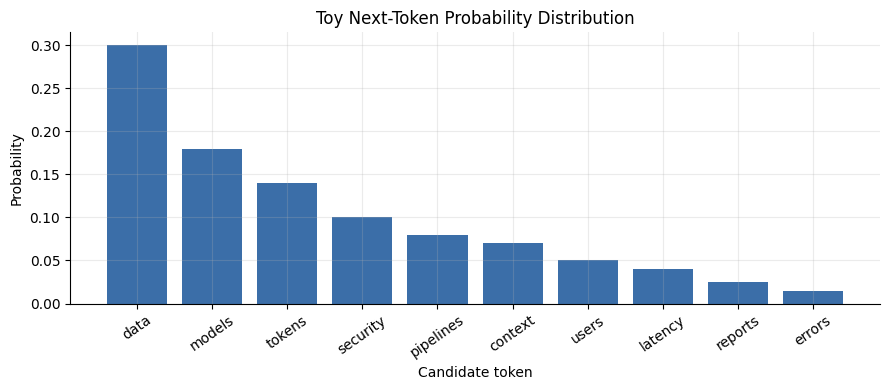

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(probability_df["token"], probability_df["probability"], color="#3b6ea8")
ax.set_title("Toy Next-Token Probability Distribution")
ax.set_xlabel("Candidate token")
ax.set_ylabel("Probability")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## Greedy Decoding

Greedy decoding always chooses the token with the highest probability.

Advantages:

- deterministic
- easy to debug
- often stable for factual or constrained tasks

Disadvantages:

- can become repetitive
- may miss better long-term continuations
- often produces less diverse text

In [5]:
def greedy_decode(token_probs):
    """Return the highest-probability token from a token-probability mapping."""
    return max(token_probs.items(), key=lambda item: item[1])

best_token, best_probability = greedy_decode(base_distribution)
print(f"Greedy choice: {best_token!r} with probability {best_probability:.3f}")

Greedy choice: 'data' with probability 0.300


## Temperature

Temperature reshapes the probability distribution before sampling.

A simple way to think about it:

- lower temperature sharpens the distribution
- temperature near 1 keeps the distribution close to the model output
- higher temperature flattens the distribution and increases randomness

Mathematically, temperature is applied to logits before softmax. In this notebook, we convert probabilities to log probabilities and apply the same idea.

In [6]:
def apply_temperature(probs, temperature=1.0):
    """Apply temperature scaling to a probability distribution."""
    if temperature <= 0:
        raise ValueError("temperature must be positive")

    probs = np.asarray(probs, dtype=float)
    logits = np.log(np.maximum(probs, 1e-12))
    scaled_logits = logits / temperature
    shifted = scaled_logits - np.max(scaled_logits)
    scaled_probs = np.exp(shifted)
    return scaled_probs / scaled_probs.sum()


temperatures = [0.3, 0.7, 1.0, 1.5, 2.0]
temperature_table = pd.DataFrame({
    f"T={temperature}": apply_temperature(probabilities, temperature)
    for temperature in temperatures
}, index=tokens)

display(temperature_table.round(3))

,T=0.3,T=0.7,T=1.0,T=1.5,T=2.0
data,0.763,0.403,0.300,0.223,0.188
models,0.139,0.194,0.180,0.159,0.146
tokens,0.060,0.136,0.140,0.134,0.128
security,0.020,0.084,0.100,0.107,0.109
pipelines,0.009,0.061,0.080,0.093,0.097
context,0.006,0.050,0.070,0.085,0.091
users,0.002,0.031,0.050,0.068,0.077
latency,0.001,0.023,0.040,0.058,0.069
reports,0.000,0.012,0.025,0.043,0.054
errors,0.000,0.006,0.015,0.030,0.042


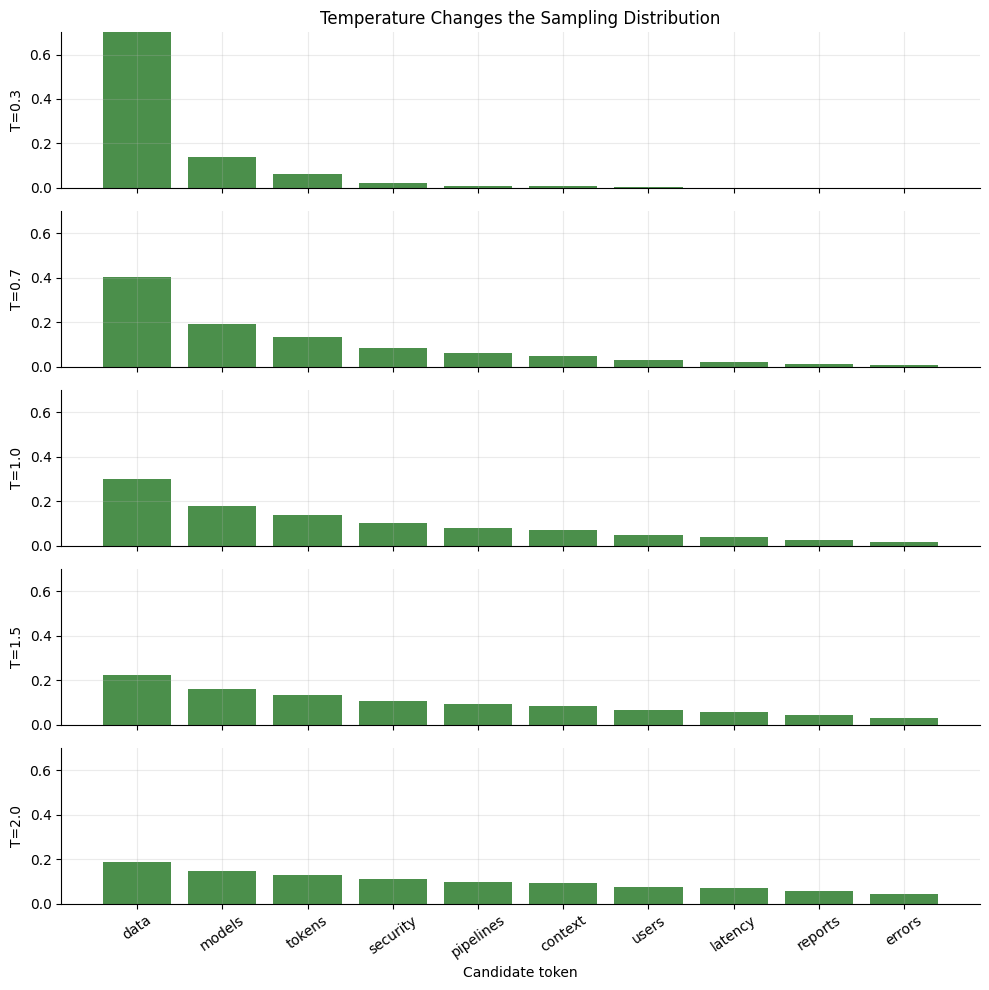

In [7]:
fig, axes = plt.subplots(len(temperatures), 1, figsize=(10, 10), sharex=True, sharey=True)

for ax, temperature in zip(axes, temperatures):
    adjusted = apply_temperature(probabilities, temperature)
    ax.bar(tokens, adjusted, color="#4b8f4b")
    ax.set_ylabel(f"T={temperature}")
    ax.set_ylim(0, 0.7)

axes[0].set_title("Temperature Changes the Sampling Distribution")
axes[-1].set_xlabel("Candidate token")
axes[-1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## Interactive Temperature Experiment

The function below samples from the same distribution using different temperatures. Re-running the cell may produce different samples because sampling is intentionally random.

In [8]:
def sample_with_temperature(token_probs, temperature=1.0, rng=None):
    """Sample one token after applying temperature."""
    if rng is None:
        rng = np.random.default_rng()

    candidate_tokens = np.array(list(token_probs.keys()))
    probs = np.array(list(token_probs.values()), dtype=float)
    adjusted_probs = apply_temperature(probs, temperature)
    sampled_token = rng.choice(candidate_tokens, p=adjusted_probs)
    return sampled_token

rng = np.random.default_rng(SEED)
temperature_samples = []
for temperature in temperatures:
    samples = [sample_with_temperature(base_distribution, temperature, rng) for _ in range(8)]
    temperature_samples.append({
        "temperature": temperature,
        "samples": " | ".join(samples),
    })

display(pd.DataFrame(temperature_samples))

,temperature,samples
0,0.3,models | data | models | data | data | securit...
1,0.7,data | models | data | context | tokens | pipe...
2,1.0,tokens | data | context | security | pipelines...
3,1.5,context | data | tokens | data | data | pipeli...
4,2.0,models | tokens | security | models | data | s...


## Top-k Sampling

Top-k sampling keeps only the `k` most likely tokens and samples from that smaller set.

This removes very unlikely tokens while still allowing variety among the strongest candidates.

In [9]:
def top_k_filter(tokens, probs, k):
    """Keep only the top-k probabilities and renormalize them."""
    if k <= 0:
        raise ValueError("k must be positive")

    k = min(k, len(probs))
    top_indices = np.argsort(probs)[::-1][:k]
    filtered_probs = np.zeros_like(probs, dtype=float)
    filtered_probs[top_indices] = probs[top_indices]
    filtered_probs = filtered_probs / filtered_probs.sum()
    return tokens, filtered_probs


def sample_top_k(token_probs, k=5, temperature=1.0, rng=None):
    """Sample using temperature followed by top-k filtering."""
    if rng is None:
        rng = np.random.default_rng()

    candidate_tokens = np.array(list(token_probs.keys()))
    probs = np.array(list(token_probs.values()), dtype=float)
    adjusted_probs = apply_temperature(probs, temperature)
    candidate_tokens, filtered_probs = top_k_filter(candidate_tokens, adjusted_probs, k)
    return rng.choice(candidate_tokens, p=filtered_probs)

for k in [5, 10]:
    kept_tokens, kept_probs = top_k_filter(tokens, probabilities, k)
    print(f"Top-k={k} kept tokens:", kept_tokens[kept_probs > 0].tolist())

Top-k=5 kept tokens: ['data', 'models', 'tokens', 'security', 'pipelines']
Top-k=10 kept tokens: ['data', 'models', 'tokens', 'security', 'pipelines', 'context', 'users', 'latency', 'reports', 'errors']


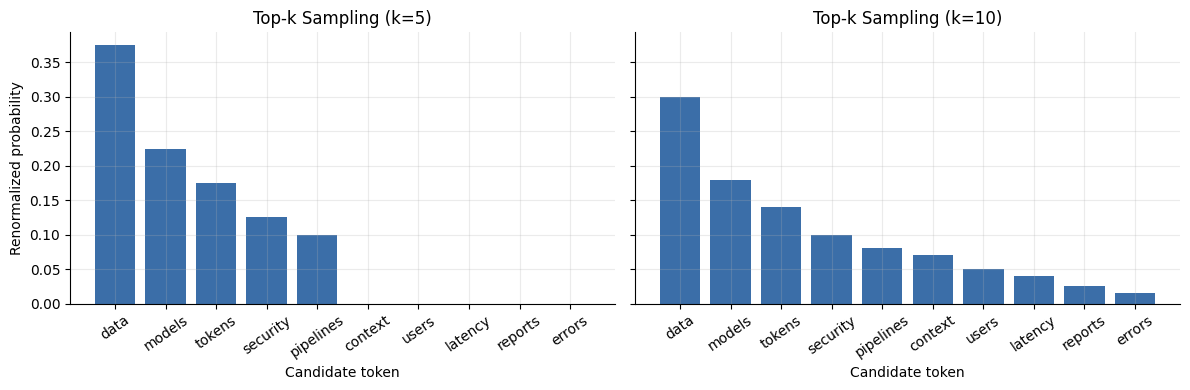

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, k in zip(axes, [5, 10]):
    _, filtered = top_k_filter(tokens, probabilities, k)
    colors = ["#3b6ea8" if value > 0 else "#dddddd" for value in filtered]
    ax.bar(tokens, filtered, color=colors)
    ax.set_title(f"Top-k Sampling (k={k})")
    ax.set_xlabel("Candidate token")
    ax.tick_params(axis="x", rotation=35)

axes[0].set_ylabel("Renormalized probability")
plt.tight_layout()
plt.show()

In [11]:
rng = np.random.default_rng(SEED)
top_k_rows = []
for k in [5, 10]:
    samples = [sample_top_k(base_distribution, k=k, temperature=1.0, rng=rng) for _ in range(10)]
    top_k_rows.append({"top_k": k, "samples": " | ".join(samples)})

display(pd.DataFrame(top_k_rows))

,top_k,samples
0,5,tokens | models | security | tokens | data | p...
1,10,models | latency | security | context | models...


## Top-p (Nucleus Sampling)

Top-p sampling keeps the smallest set of tokens whose cumulative probability reaches a threshold `p`.

Instead of choosing a fixed number of tokens, top-p adapts to the shape of the distribution. If the model is confident, the nucleus may be small. If the model is uncertain, the nucleus may include more tokens.

In [12]:
def top_p_filter(tokens, probs, p=0.9):
    """Keep the smallest token set whose cumulative probability reaches p."""
    if not 0 < p <= 1:
        raise ValueError("p must be in the interval (0, 1]")

    sorted_indices = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_indices]
    cumulative = np.cumsum(sorted_probs)
    keep_sorted = cumulative <= p
    keep_sorted[0] = True

    first_above = np.argmax(cumulative >= p)
    keep_sorted[:first_above + 1] = True

    filtered_probs = np.zeros_like(probs, dtype=float)
    kept_indices = sorted_indices[keep_sorted]
    filtered_probs[kept_indices] = probs[kept_indices]
    filtered_probs = filtered_probs / filtered_probs.sum()
    return tokens, filtered_probs, sorted_indices, cumulative

_, top_p_probs, sorted_indices, cumulative = top_p_filter(tokens, probabilities, p=0.85)

top_p_df = pd.DataFrame({
    "token": tokens[sorted_indices],
    "probability": probabilities[sorted_indices],
    "cumulative_probability": cumulative,
    "kept_for_top_p_0.85": top_p_probs[sorted_indices] > 0,
})
display(top_p_df)

,token,probability,cumulative_probability,kept_for_top_p_0.85
0,data,0.300,0.300,True
1,models,0.180,0.480,True
2,tokens,0.140,0.620,True
3,security,0.100,0.720,True
4,pipelines,0.080,0.800,True
5,context,0.070,0.870,True
6,users,0.050,0.920,False
7,latency,0.040,0.960,False
8,reports,0.025,0.985,False
9,errors,0.015,1.000,False


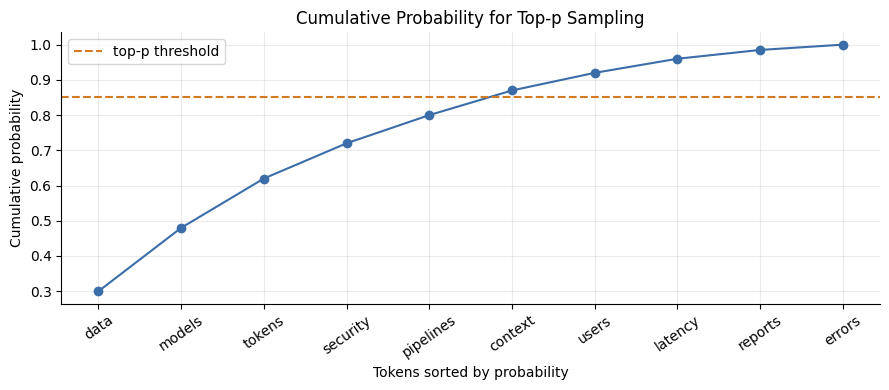

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tokens[sorted_indices], cumulative, marker="o", color="#3b6ea8")
ax.axhline(0.85, color="#d17a22", linestyle="--", label="top-p threshold")
ax.set_title("Cumulative Probability for Top-p Sampling")
ax.set_xlabel("Tokens sorted by probability")
ax.set_ylabel("Cumulative probability")
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
def sample_top_p(token_probs, p=0.9, temperature=1.0, rng=None):
    """Sample using temperature followed by top-p filtering."""
    if rng is None:
        rng = np.random.default_rng()

    candidate_tokens = np.array(list(token_probs.keys()))
    probs = np.array(list(token_probs.values()), dtype=float)
    adjusted_probs = apply_temperature(probs, temperature)
    candidate_tokens, filtered_probs, _, _ = top_p_filter(candidate_tokens, adjusted_probs, p=p)
    return rng.choice(candidate_tokens, p=filtered_probs)

rng = np.random.default_rng(SEED)
top_p_samples = []
for p_value in [0.7, 0.85, 0.95]:
    samples = [sample_top_p(base_distribution, p=p_value, temperature=1.0, rng=rng) for _ in range(10)]
    top_p_samples.append({"top_p": p_value, "samples": " | ".join(samples)})

display(pd.DataFrame(top_p_samples))

,top_p,samples
0,0.70,tokens | models | tokens | tokens | data | sec...
1,0.85,models | context | tokens | security | models ...
2,0.95,pipelines | models | latency | context | pipel...


## Comparing Decoding Strategies

Each decoding strategy makes a different trade-off between stability and diversity.

In [15]:
comparison_df = pd.DataFrame({
    "strategy": ["Greedy", "Temperature", "Top-k", "Top-p"],
    "main idea": [
        "always choose highest probability",
        "reshape probabilities before sampling",
        "sample only from k strongest tokens",
        "sample from cumulative probability nucleus",
    ],
    "creativity": ["low", "adjustable", "medium", "medium-high"],
    "stability": ["high", "adjustable", "medium", "medium"],
    "randomness": ["none", "controlled", "bounded", "adaptive"],
    "common use": [
        "deterministic tasks",
        "general generation control",
        "avoid unlikely tokens",
        "open-ended generation",
    ],
})

display(comparison_df)

,strategy,main idea,creativity,stability,randomness,common use
0,Greedy,always choose highest probability,low,high,none,deterministic tasks
1,Temperature,reshape probabilities before sampling,adjustable,adjustable,controlled,general generation control
2,Top-k,sample only from k strongest tokens,medium,medium,bounded,avoid unlikely tokens
3,Top-p,sample from cumulative probability nucleus,medium-high,medium,adaptive,open-ended generation


## Autoregressive Generation

Autoregressive generation means each predicted token becomes part of the next input.

The model does not generate a full paragraph in one step. It generates one token, updates the context, and repeats.

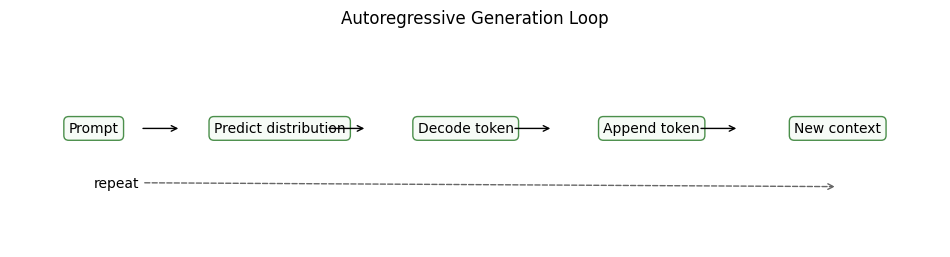

In [16]:
flow_steps = ["Prompt", "Predict distribution", "Decode token", "Append token", "New context"]
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")
ax.set_xlim(0, len(flow_steps))
ax.set_ylim(0, 1)

for idx, step in enumerate(flow_steps):
    ax.text(
        idx + 0.45,
        0.55,
        step,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#f6fbf6", edgecolor="#4b8f4b"),
    )
    if idx < len(flow_steps) - 1:
        ax.annotate("", xy=(idx + 0.92, 0.55), xytext=(idx + 0.70, 0.55), arrowprops=dict(arrowstyle="->"))

ax.annotate("repeat", xy=(4.45, 0.28), xytext=(0.45, 0.28), arrowprops=dict(arrowstyle="->", linestyle="--", color="#666666"))
ax.set_title("Autoregressive Generation Loop")
plt.show()

## A Tiny Toy Language Model

To experiment with decoding, we need a model-like object that returns a probability distribution for the next token.

The toy model below is not trained. It uses hand-written transition probabilities so the decoding strategies are easy to inspect.

In [17]:
toy_transitions = {
    "the": {"model": 0.35, "system": 0.20, "assistant": 0.18, "pipeline": 0.15, "data": 0.12},
    "model": {"predicts": 0.28, "learns": 0.25, "generates": 0.20, "uses": 0.15, "explains": 0.12},
    "system": {"monitors": 0.30, "reports": 0.22, "reduces": 0.18, "detects": 0.17, "summarizes": 0.13},
    "assistant": {"answers": 0.30, "summarizes": 0.24, "explains": 0.20, "generates": 0.16, "reviews": 0.10},
    "pipeline": {"cleans": 0.30, "validates": 0.25, "loads": 0.20, "transforms": 0.15, "monitors": 0.10},
    "data": {"pipelines": 0.25, "quality": 0.22, "signals": 0.18, "records": 0.18, "patterns": 0.17},
    "predicts": {"tokens": 0.32, "labels": 0.22, "outcomes": 0.18, "errors": 0.14, "latency": 0.14},
    "learns": {"patterns": 0.35, "context": 0.25, "features": 0.18, "signals": 0.12, "tokens": 0.10},
    "generates": {"text": 0.34, "tokens": 0.24, "answers": 0.18, "summaries": 0.14, "ideas": 0.10},
    "uses": {"context": 0.30, "attention": 0.25, "probabilities": 0.20, "tokens": 0.15, "signals": 0.10},
}

def get_next_token_distribution(context_tokens):
    """Return a toy next-token distribution based on the last token."""
    last_token = context_tokens[-1].lower() if context_tokens else "the"
    distribution = toy_transitions.get(last_token, base_distribution)
    distribution = OrderedDict(distribution)
    total = sum(distribution.values())
    return OrderedDict((token, prob / total) for token, prob in distribution.items())

display(pd.DataFrame(get_next_token_distribution(["the"]).items(), columns=["token", "probability"]))

,token,probability
0,model,0.35
1,system,0.20
2,assistant,0.18
3,pipeline,0.15
4,data,0.12


## Mini Project: Text Generation Playground

The `generate_text()` function supports greedy decoding, temperature sampling, top-k sampling, and top-p sampling.

Parameters:

- `temperature`: reshapes the distribution
- `top_k`: keeps only the strongest `k` options
- `top_p`: keeps the nucleus of cumulative probability
- `max_tokens`: controls continuation length

In [18]:
def decode_next_token(distribution, strategy="temperature", temperature=1.0, top_k=None, top_p=None, rng=None):
    """Decode one token from a probability distribution."""
    if rng is None:
        rng = np.random.default_rng()

    if strategy == "greedy":
        return greedy_decode(distribution)[0]

    candidate_tokens = np.array(list(distribution.keys()))
    probs = np.array(list(distribution.values()), dtype=float)
    probs = apply_temperature(probs, temperature)

    if top_k is not None:
        candidate_tokens, probs = top_k_filter(candidate_tokens, probs, top_k)

    if top_p is not None:
        candidate_tokens, probs, _, _ = top_p_filter(candidate_tokens, probs, top_p)

    return rng.choice(candidate_tokens, p=probs)


def generate_text(prompt, temperature=1.0, top_k=None, top_p=None, max_tokens=12, strategy="temperature", seed=SEED):
    """Generate text with a toy autoregressive language model."""
    rng = np.random.default_rng(seed)
    generated_tokens = prompt.lower().split()

    for _ in range(max_tokens):
        distribution = get_next_token_distribution(generated_tokens)
        next_token = decode_next_token(
            distribution,
            strategy=strategy,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            rng=rng,
        )
        generated_tokens.append(next_token)

    return " ".join(generated_tokens)

examples = [
    generate_text("the", strategy="greedy", max_tokens=10),
    generate_text("the", temperature=0.7, max_tokens=10),
    generate_text("the", temperature=1.2, top_k=3, max_tokens=10),
    generate_text("the", temperature=1.0, top_p=0.8, max_tokens=10),
]

for text in examples:
    print(text)

the model predicts tokens data pipelines data pipelines data pipelines data
the assistant summarizes pipelines tokens data patterns security security data quality
the assistant summarizes tokens models data records tokens tokens data quality
the assistant summarizes pipelines tokens data records security security data quality


In [19]:
playground_rows = [
    {
        "strategy": "greedy",
        "settings": "argmax",
        "generated_text": generate_text("the", strategy="greedy", max_tokens=12),
    },
    {
        "strategy": "temperature",
        "settings": "T=0.7",
        "generated_text": generate_text("the", temperature=0.7, max_tokens=12),
    },
    {
        "strategy": "top-k",
        "settings": "T=1.0, k=3",
        "generated_text": generate_text("the", temperature=1.0, top_k=3, max_tokens=12),
    },
    {
        "strategy": "top-p",
        "settings": "T=1.0, p=0.8",
        "generated_text": generate_text("the", temperature=1.0, top_p=0.8, max_tokens=12),
    },
    {
        "strategy": "high temperature",
        "settings": "T=1.8",
        "generated_text": generate_text("the", temperature=1.8, max_tokens=12),
    },
]

playground_df = pd.DataFrame(playground_rows)
display(playground_df)

,strategy,settings,generated_text
0,greedy,argmax,the model predicts tokens data pipelines data ...
1,temperature,T=0.7,the assistant summarizes pipelines tokens data...
2,top-k,"T=1.0, k=3",the assistant summarizes tokens models data re...
3,top-p,"T=1.0, p=0.8",the assistant summarizes pipelines tokens data...
4,high temperature,T=1.8,the pipeline validates latency context data pa...


## Sampling Comparison Visualization

A compact way to compare strategies is to count which tokens appear in several generated continuations.

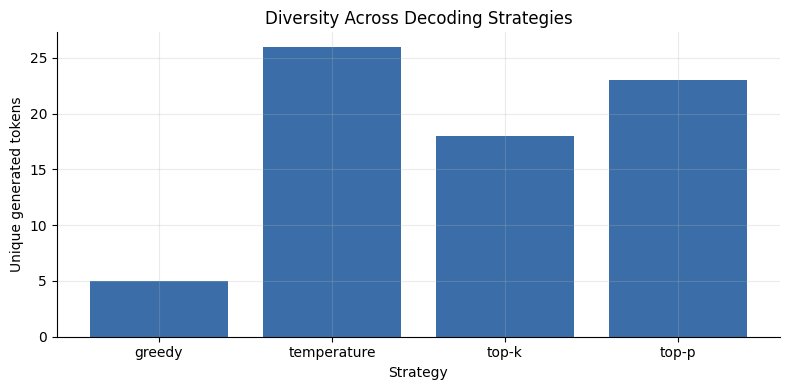

,strategy,unique_generated_tokens
0,greedy,5
1,temperature,26
2,top-k,18
3,top-p,23


In [20]:
strategies = {
    "greedy": {"strategy": "greedy"},
    "temperature": {"temperature": 1.0},
    "top-k": {"temperature": 1.0, "top_k": 3},
    "top-p": {"temperature": 1.0, "top_p": 0.8},
}

sampled_counts = []
for strategy_name, kwargs in strategies.items():
    all_tokens = []
    for seed in range(10):
        text = generate_text("the", max_tokens=8, seed=seed, **kwargs)
        all_tokens.extend(text.split()[1:])
    unique_count = len(set(all_tokens))
    sampled_counts.append({"strategy": strategy_name, "unique_generated_tokens": unique_count})

sampled_counts_df = pd.DataFrame(sampled_counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sampled_counts_df["strategy"], sampled_counts_df["unique_generated_tokens"], color="#3b6ea8")
ax.set_title("Diversity Across Decoding Strategies")
ax.set_xlabel("Strategy")
ax.set_ylabel("Unique generated tokens")
plt.tight_layout()
plt.show()

display(sampled_counts_df)

## Practical Recommendations

- Use low temperature when you want stable, focused, less surprising answers.
- Use higher temperature when you want brainstorming, variation, or creative exploration.
- Use top-k when you want to block very unlikely tokens while keeping a fixed candidate pool.
- Use top-p when you want the candidate pool to adapt to model confidence.
- Use greedy decoding for deterministic baselines, constrained tasks, or debugging.

ChatGPT-style systems often use tuned combinations of temperature and nucleus sampling, plus additional safety and quality controls outside the basic decoding algorithm.

## Common Mistakes

Common decoding mistakes include:

- using too much randomness and getting unstable text
- using too little randomness and getting repetitive or generic text
- allowing repeated tokens or repeated phrases without controls
- assuming decoding can fully prevent hallucinations
- confusing high probability with guaranteed truth
- using greedy decoding and calling the result the only correct answer

Decoding changes how model probabilities are used. It does not create knowledge that the model did not learn.

## Final Summary

Key takeaways:

- inference uses model probabilities to choose generated tokens
- greedy decoding chooses the highest-probability token
- temperature controls how sharp or flat the distribution becomes
- top-k sampling keeps a fixed number of likely candidates
- top-p sampling keeps an adaptive cumulative-probability nucleus
- autoregressive generation repeats prediction, decoding, and appending
- decoding strategy strongly affects stability, creativity, and repetition

## Next Notebook

➡️ Next: Quantization

Now that we know how LLMs generate text, the next challenge is making them smaller, faster, and cheaper to run.